<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.shape

(985, 12)

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [3]:
housing = housing.drop_duplicates()
housing = housing[housing['sq__ft'] > 0]
housing['sale_date'] = pd.to_datetime(housing['sale_date'], format="%a %b %d %H:%M:%S EDT %Y")
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [4]:
#city, beds, bath, sq__ft, latitude, longitude
housing.corr(numeric_only = True).style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,zip,beds,baths,sq__ft,price,latitude,longitude
zip,1.00,-0.07,-0.10,-0.10,-0.22,-0.13,-0.56
beds,-0.07,1.00,0.65,0.70,0.44,-0.11,0.05
baths,-0.10,0.65,1.00,0.72,0.50,-0.08,0.11
sq__ft,-0.10,0.70,0.72,1.00,0.69,-0.10,0.13
price,-0.22,0.44,0.50,0.69,1.00,0.06,0.28
latitude,-0.13,-0.11,-0.08,-0.10,0.06,1.00,0.35
longitude,-0.56,0.05,0.11,0.13,0.28,0.35,1.00


### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [5]:
housing['sq__ft'] # because it has the highest correlation with the price

0       836
1      1167
2       796
3       852
4       797
       ... 
980    2280
981    1477
982    1216
983    1685
984    1362
Name: sq__ft, Length: 811, dtype: int64

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [6]:
def slope_and_intercept(X,y):
    X_mean = X.mean()
    y_mean = y.mean()
    X_std = X.std()
    y_std = y.std()
    r_xy = np.corrcoef(X,y)[0,1]
    b1 = r_xy * (y_std/X_std)
    b0 = y_mean - b1*X_mean
    return b1,b0
    

In [7]:
X = housing['sq__ft']
y = housing['price']
slope_and_intercept(X,y)

(np.float64(125.15261406074984), np.float64(30352.243076665152))

### 6. Interpret the intercept and the slope.

In [8]:
#for every unit increase in sq_ft the price icrease by 125, and the intreception of the y axis is at 30352

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

In [9]:
# in prediction, our primary goal is to use the model to accurately estimate the market value of a specific house given its square footage, regardless of why the relationship exists
#Example: A real estate agent has a new listing for a house that is 2,000 sq ft. They want to know what price to list it at

#In inference, your primary goal is to understand the structure of the relationship between square footage and house prices—specifically, how changes in one variable impact or relate to the other
#Example: A housing market analyst wants to understand the exact economic impact of expanding a home's size or whether square footage is a statistically meaningful driver of price


### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



In [10]:
housing['type'].unique()

<ArrowStringArray>
['Residential', 'Condo', 'Multi-Family']
Length: 3, dtype: str

#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [11]:
housing = pd.get_dummies(housing, columns=['type'], drop_first=True, dtype=int)
housing

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,2008-05-15,232425,38.457679,-121.359620,0,1
981,6932 RUSKUT WAY,SACRAMENTO,95823,CA,3,2,1477,2008-05-15,234000,38.499893,-121.458890,0,1
982,7933 DAFFODIL WAY,CITRUS HEIGHTS,95610,CA,3,2,1216,2008-05-15,235000,38.708824,-121.256803,0,1
983,8304 RED FOX WAY,ELK GROVE,95758,CA,4,2,1685,2008-05-15,235301,38.417000,-121.397424,0,1


### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [12]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,type_Multi-Family,type_Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [13]:
X = housing[['sq__ft','beds','type_Multi-Family','type_Residential']]
y= housing['price']
model = LinearRegression()
model.fit(X,y)
housing['y_pred'] = model.predict(X)
print(model.intercept_)
print(model.coef_)

24787.02963329741
[   134.89110793 -12614.87253008 -20082.32004833  33578.5644194 ]


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

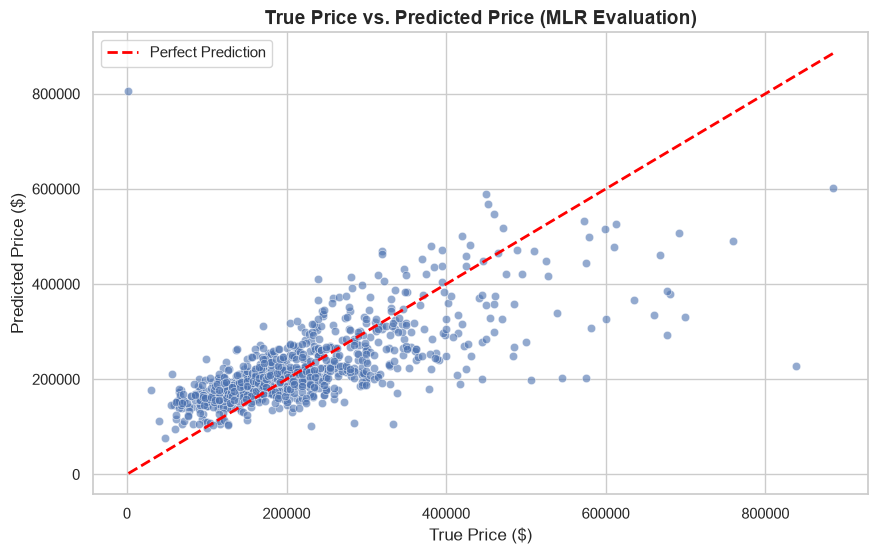

In [14]:

# Set the style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(x=housing['price'], y=housing['y_pred'], alpha=0.6, color='b')

# Add a diagonal line of perfect prediction
perfect_line = [housing['price'].min(), housing['price'].max()]
plt.plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Labels and Title
plt.xlabel('True Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title('True Price vs. Predicted Price (MLR Evaluation)', fontsize=14, fontweight='bold')
plt.legend()

# Show the plot
plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

#1- Linearity
#2- Independence of Errors
#3- Constant Variance
#4- Normality of Errors
#5- No Multicollinearity

### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

In [15]:
#Linearity: was Met, and that is obvious in the oplot
#No Multicollinearity: was Moderately Met, correlation between beds and sq__ft was 0.7


### 15. Regression Metrics

Implement a function called `r2_adj()` that will calculate $R^2_{adj}$ for a model.

The adjusted R-squared is calculated as $R^2_{adj} = 1 - \left[ \frac{(1 - R^2)(n - 1)}{n - k - 1} \right]$.

Unlike standard R-squared, which always increases when you add new variables, Adjusted R-squared will actually decrease if you add a useless variable to your model. This helps you find the simplest and most effective model.
- $R^2$: The standard R-squared value (coefficient of determination)
- $n$: The total number of observations (sample size)
- $k$: The number of independent variables (predictors) in your model

In [16]:
def r2_adj(data,model, X, y):
    up = ((1- model.score(X,y))*(data.shape[0] - 1))
    down = (data.shape[0]- len(X.columns) - 1)
    result = 1- (up/down)
    return result

### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [17]:
mae = mean_absolute_error(y, housing['y_pred'])
rmse = np.sqrt(mean_squared_error(y, housing['y_pred']))
r2 = r2_score(y, housing['y_pred'])
adj_r2 = r2_adj(housing, model, X, y)
# Print results
print(f"MAE:  ${mae}")
print(f"RMSE: ${rmse}")
print(f"R2:   {r2}")
print(f"Adjusted R2:   {adj_r2}")

MAE:  $59100.301571141135
RMSE: $85543.48269030043
R2:   0.49027551334611297
Adjusted R2:   0.4877458632882773


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [18]:
X = housing[['sq__ft','type_Multi-Family','type_Residential']]
y= housing['price']
model = LinearRegression()
model.fit(X,y)
housing['y_pred'] = model.predict(X)


mae = mean_absolute_error(y, housing['y_pred'])
rmse = np.sqrt(mean_squared_error(y, housing['y_pred']))
r2 = r2_score(y, housing['y_pred'])
adj_r2 = r2_adj(housing, model, X, y)
# Print results
print(f"MAE:  ${mae}")
print(f"RMSE: ${rmse}")
print(f"R2:   {r2}")
print(f"Adjusted R2:   {adj_r2}")

MAE:  $59824.02151166651
RMSE: $85846.72398837628
R2:   0.48665528477368314
Adjusted R2:   0.48474694010741426


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [19]:
housing['city'].value_counts()

city
SACRAMENTO         422
ELK GROVE          107
CITRUS HEIGHTS      34
ANTELOPE            33
ROSEVILLE           28
RANCHO CORDOVA      21
NORTH HIGHLANDS     21
GALT                20
CARMICHAEL          20
FOLSOM              15
RIO LINDA           12
ORANGEVALE          11
FAIR OAKS            9
ROCKLIN              8
LINCOLN              6
PLACERVILLE          5
ELVERTA              4
WILTON               4
POLLOCK PINES        3
GOLD RIVER           3
AUBURN               3
EL DORADO HILLS      3
GRANITE BAY          3
RANCHO MURIETA       2
LOOMIS               2
EL DORADO            2
MATHER               1
GREENWOOD            1
MEADOW VISTA         1
CAMERON PARK         1
PENRYN               1
DIAMOND SPRINGS      1
COOL                 1
WALNUT GROVE         1
SLOUGHHOUSE          1
WEST SACRAMENTO      1
Name: count, dtype: int64

In [20]:
city_counts = housing['city'].value_counts()
rare_cities = city_counts[city_counts < 20].index
housing['city'] = housing['city'].replace(rare_cities, 'Other')


# Initialize and configure the encoder just like you did
ohe = OneHotEncoder(sparse_output=False, drop='first')
ohe.set_output(transform='pandas')

# Fit and transform the processed column
cat_cols = ['city']
encoded_df = ohe.fit_transform(housing[cat_cols])

# Ensure all columns are clean integers (0 or 1)
encoded_df = encoded_df.astype(int)

# Drop the old text column and bring in the new DataFrame seamlessly
housing = housing.drop(columns=['city']).join(encoded_df)

housing.head()

,street,zip,state,beds,baths,sq__ft,sale_date,price,latitude,longitude,...,y_pred,city_CARMICHAEL,city_CITRUS HEIGHTS,city_ELK GROVE,city_GALT,city_NORTH HIGHLANDS,city_Other,city_RANCHO CORDOVA,city_ROSEVILLE,city_SACRAMENTO
0,3526 HIGH ST,95838,CA,2,1,836,2008-05-21,59222,38.631913,-121.434879,...,137586.108373,0,0,0,0,0,0,0,0,1
1,51 OMAHA CT,95823,CA,3,1,1167,2008-05-21,68212,38.478902,-121.431028,...,178825.847543,0,0,0,0,0,0,0,0,1
2,2796 BRANCH ST,95815,CA,2,1,796,2008-05-21,68880,38.618305,-121.443839,...,132602.454093,0,0,0,0,0,0,0,0,1
3,2805 JANETTE WAY,95815,CA,2,1,852,2008-05-21,69307,38.616835,-121.439146,...,139579.570085,0,0,0,0,0,0,0,0,1
4,6001 MCMAHON DR,95824,CA,2,1,797,2008-05-21,81900,38.519470,-121.435768,...,132727.045450,0,0,0,0,0,0,0,0,1


In [21]:
len(rare_cities)

27

## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [25]:
baseline_pred = y.mean()
baseline_mae = np.mean(np.sqrt((y - baseline_pred) ** 2))
mlr_mae = mean_absolute_error(y, housing['y_pred'])

average_savings = baseline_mae - mlr_mae

print(f"Baseline (the naive guess): {baseline_mae}")
print(f"Our Model: {mlr_mae}")
print(baseline_mae - mlr_mae)

Baseline (the naive guess): 88310.56118019647
Our Model: 59824.02151166651
28486.539668529957


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [31]:
features = ['sq__ft', 'beds', 'type_Multi-Family', 'type_Residential']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(housing[features])
lr = LinearRegression()
lr.fit(X_scaled, housing['price'])
coef_series = pd.Series(lr.coef_, index=features)
abs_weights = np.sqrt(coef_series ** 2)

best_feature = abs_weights.sort_values(ascending=False).index[0]
print(f"The most feature my model relies on is: {best_feature}")

The most feature my model relies on is: sq__ft


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [33]:
features = ['sq__ft', 'beds', 'type_Multi-Family', 'type_Residential']
X = housing[features]
y = housing['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training RMSE: {train_rmse}")
print(f"Testing RMSE:  {test_rmse}")

Training RMSE: 88443.24836968287
Testing RMSE:  73057.70549250479


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

- **Not High Variance: (not overfitting)** The test error ($\approx \$73\text{k}$) is lower than the train error ($\approx \$88\text{k}$), showing zero performance drop-off or overfitting on unseen data.
- **Is High Bias: (underfitting)** The model is too simple; an error of $\$73\text{k}-\$88\text{k}$ is quite high for $\$100\text{k}-\$300\text{k}$ homes because using only four features misses crucial details like location and property condition.

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

In [36]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

# 1. One-Hot Encode ALL raw cities directly
ohe_city = OneHotEncoder(sparse_output=False, drop='first')
ohe_city.set_output(transform='pandas')
city_dummies = ohe_city.fit_transform(housing[['city']]).astype(int)

# 2. One-Hot Encode 'type' as well so base_features exist
ohe_type = OneHotEncoder(sparse_output=False, drop='first')
ohe_type.set_output(transform='pandas')
type_dummies = ohe_type.fit_transform(housing[['type']]).astype(int)

# 3. Build feature matrix X
X = housing[['sq__ft', 'beds']].copy()
X[type_dummies.columns] = type_dummies
X[city_dummies.columns] = city_dummies

y = housing['price']

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Fit & Evaluate
model = LinearRegression()
model.fit(X_train, y_train)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2 = r2_score(y_test, model.predict(X_test))

print(f"Training R-squared: {train_r2}")
print(f"Testing R-squared:  {test_r2}")
print(f"Gap (Train - Test): {train_r2 - test_r2}")

Training R-squared: 0.5272019989740957
Testing R-squared:  0.4402892643494052
Gap (Train - Test): 0.08691273462469051


### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?

#This gap illustrates overfitting-High Variance. When faced with new houses in the test set, those hyper-specific city rules failed to generalize, causing test accuracy to take a noticeable hit.